# Transformer 핵심 실습

# 단일토큰 Self Attention 실습

In [1]:
import torch
import torch.nn.functional as F

In [2]:
from transformers import AutoTokenizer

sentence = "The apple is on the table"

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# 토큰 문자열로 보기
print("토큰 문자열로 보기 => ", tokenizer.tokenize(sentence))
# ['the', 'apple', 'is', 'on', 'the', 'table']

# 모델 입력용 (특수토큰 [CLS]/[SEP], 텐서 포함)
enc = tokenizer(sentence, return_tensors="pt")
print('enc["input_ids"] => ', enc["input_ids"])             # 토큰의 정수 번호 시퀀스
print('enc["attention_mask"] => ', enc["attention_mask"])   # 실제 토큰은 1, 패딩(채움)은 0

# 다시 토큰으로 복원
print("토큰 복원 => ", tokenizer.convert_ids_to_tokens(enc["input_ids"][0]))
#  ['[CLS]', 'the', 'apple', 'is', 'on', 'the', 'table', '[SEP]']
#  [CLS](문장 시작), [SEP](문장 끝) 같은 특수 토큰을 자동으로 추가

# 디코딩
print("디코딩 => ", tokenizer.decode(enc["input_ids"][0]))


토큰 문자열로 보기 =>  ['the', 'apple', 'is', 'on', 'the', 'table']
enc["input_ids"] =>  tensor([[ 101, 1996, 6207, 2003, 2006, 1996, 2795,  102]])
enc["attention_mask"] =>  tensor([[1, 1, 1, 1, 1, 1, 1, 1]])
토큰 복원 =>  ['[CLS]', 'the', 'apple', 'is', 'on', 'the', 'table', '[SEP]']
디코딩 =>  [CLS] the apple is on the table [SEP]


## Query, Key, Value로 Self Attention 실습

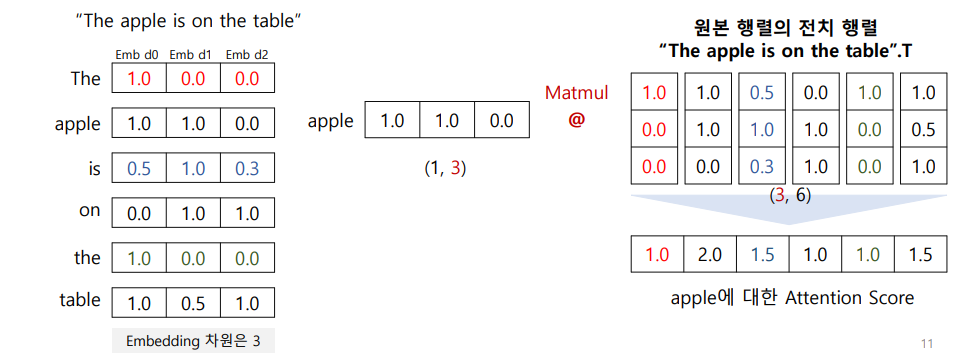

In [3]:
sentence = "The apple is on the table"
tokens = sentence.split()
tokens

['The', 'apple', 'is', 'on', 'the', 'table']

In [4]:
# 테스트용 값으로 embeddings tensor 값을 생성함
token_embeddings = torch.tensor([
    [1.0, 0.0, 0.0],   # The
    [1.0, 1.0, 0.0],   # apple
    [0.5, 1.0, 0.3],   # is
    [0.0, 1.0, 1.0],   # on
    [1.0, 0.0, 0.0],   # the
    [1.0, 0.5, 1.0]    # table
]) # shape : (6, 3)

In [5]:
token_embeddings.shape

torch.Size([6, 3])

In [6]:
# token 'apple'과 다른 토큰간의 attention score 계산하기
apple_query = token_embeddings[1]    # [1.0, 1.0, 0.0]
apple_query

tensor([1., 1., 0.])

In [7]:
# 그대로 복사
keys = token_embeddings.clone()
keys

tensor([[1.0000, 0.0000, 0.0000],
        [1.0000, 1.0000, 0.0000],
        [0.5000, 1.0000, 0.3000],
        [0.0000, 1.0000, 1.0000],
        [1.0000, 0.0000, 0.0000],
        [1.0000, 0.5000, 1.0000]])

In [8]:
keys.T

tensor([[1.0000, 1.0000, 0.5000, 0.0000, 1.0000, 1.0000],
        [0.0000, 1.0000, 1.0000, 1.0000, 0.0000, 0.5000],
        [0.0000, 0.0000, 0.3000, 1.0000, 0.0000, 1.0000]])

In [9]:
# (1, 3) @ (3, 6)
# apple_attn_scores = apple_query @ token_embeddings.T 
apple_attn_scores = apple_query @ keys.T
apple_attn_scores 

tensor([1.0000, 2.0000, 1.5000, 1.0000, 1.0000, 1.5000])

## 단일 토큰에 대한 attention weights 계산하기
- attention score 값에 대해서 softmax로 정규화 적용(전체 sum이 1이 되도록 적용).  
- embedding 차원 개수로의 scale 작업은 일단 수행하지 않음

여기 그림 넣기

In [10]:
# attention score 값에 대해서 softmax로 정규화 적용(전체 sum이 1이 되도록 적용). 
# embedding 차원 개수로의 scale 작업은 일단 수행하지 않음
# 1차원에 대한 softmax 적용이므로 dim이 불필요 할 수도 있지만, 
# 함수에서 명시적으로 설정할 것을 요구

In [11]:
import torch.nn.functional as F

reads_attn_weights = F.softmax(apple_attn_scores, dim= -1)
print(f"apple_attn_weights : {reads_attn_weights}")

apple_attn_weights : tensor([0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829])


In [12]:
# softmax를 통과한 값의 합은 1
reads_attn_weights.sum()

tensor(1.)

## 단일 토큰의 context vector 값 구하기
- 개별 단어의 Attention Weights를 반영하여 문장 문맥 의미가 적용된 단어 만들기

In [ ]:
apple_query = token_embeddings[1]   # tensor([1., 1., 0.])
# apple의 key
keys = token_embeddings.clone()
keys

tensor([[1.0000, 0.0000, 0.0000],
        [1.0000, 1.0000, 0.0000],
        [0.5000, 1.0000, 0.5000],
        [0.0000, 1.0000, 1.0000],
        [1.0000, 0.0000, 0.0000],
        [1.0000, 0.5000, 1.0000]])

In [14]:
# apple token의 context vector를 구하기 위한 values
values = token_embeddings.clone()
values

tensor([[1.0000, 0.0000, 0.0000],
        [1.0000, 1.0000, 0.0000],
        [0.5000, 1.0000, 0.3000],
        [0.0000, 1.0000, 1.0000],
        [1.0000, 0.0000, 0.0000],
        [1.0000, 0.5000, 1.0000]])

In [15]:
# apple의 attention weight 구하기
apple_attn_weight = F.softmax(apple_query @ keys.T, dim = -1)
print(f"apple_attn_weight: {apple_attn_weight}")

apple_attn_weight: tensor([0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829])


In [16]:
# apple token의 context vector 값 구하기
# (1, 6) @ (6, 3)
apple_contex_vec = apple_attn_weight @ values
print(f"apple_context_vec: {apple_contex_vec}")

apple_context_vec: tensor([0.7976, 0.6867, 0.3487])


In [17]:
# 전체 query token들의 attention weights를 시뮬레이션하기 위해서 
# 개별 query token들을 loop 방식으로 차례로 q @ K.T 적용

attn_weights_matrix_temp = torch.empty(token_embeddings.shape[0], token_embeddings.shape[0])
print(attn_weights_matrix_temp.shape)

torch.Size([6, 6])


In [18]:
queries = token_embeddings.clone()
keys = token_embeddings.clone()

# 전체 token들을 순차적으로 loop를 돌면서 attention_weight를 구함. 
for idx, query_token in enumerate(queries):
    attn_weight = F.softmax(query_token @ keys.T, dim=-1)
    print(f"token {tokens[idx]}: {query_token}'s attn_weight: {attn_weight}")
    attn_weights_matrix_temp[idx] = attn_weight

print(f"\nattn_weights_matrix_temp:\n{attn_weights_matrix_temp}")

token The: tensor([1., 0., 0.])'s attn_weight: tensor([0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010])
token apple: tensor([1., 1., 0.])'s attn_weight: tensor([0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829])
token is: tensor([0.5000, 1.0000, 0.3000])'s attn_weight: tensor([0.0871, 0.2367, 0.2017, 0.1938, 0.0871, 0.1938])
token on: tensor([0., 1., 1.])'s attn_weight: tensor([0.0494, 0.1342, 0.1811, 0.3647, 0.0494, 0.2212])
token the: tensor([1., 0., 0.])'s attn_weight: tensor([0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010])
token table: tensor([1.0000, 0.5000, 1.0000])'s attn_weight: tensor([0.0986, 0.1626, 0.1332, 0.1626, 0.0986, 0.3443])

attn_weights_matrix_temp:
tensor([[0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829],
        [0.0871, 0.2367, 0.2017, 0.1938, 0.0871, 0.1938],
        [0.0494, 0.1342, 0.1811, 0.3647, 0.0494, 0.2212],
        [0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.0986, 0.1626, 0.1332, 

# 문장내 모든 token들의 attention weights 구하기

* Q = token_embeddings, K = token_embeddings 일때 
* Softmax(Q @ K.T) 로 문장내 모든 token들의 attention weights 계산(정방 행렬이 됨)
* 생성된 attention weights의 shape는 (문장 sequence length, 문장 sequence length)가 됨.
* 즉 위의 token_embeddings는 6개의 token들(문장 sequence length가 6)로 구성되어 있으므로 attention weights의 shape는 (6, 6)

In [19]:
# matrix multiplication으로 모든 token들의 attention weight를 matrix 형태로 구하기
queries = token_embeddings.clone()
keys = token_embeddings.clone()

# attention score 계산
attn_scores = queries @ keys.T
# softmax 정규화 적용. dim = -1
attn_weights = F.softmax(attn_scores, dim=-1)

print(f"attn_scores:\n{attn_scores}")
print(f"attn_weights:\n{attn_weights}")

attn_scores:
tensor([[1.0000, 1.0000, 0.5000, 0.0000, 1.0000, 1.0000],
        [1.0000, 2.0000, 1.5000, 1.0000, 1.0000, 1.5000],
        [0.5000, 1.5000, 1.3400, 1.3000, 0.5000, 1.3000],
        [0.0000, 1.0000, 1.3000, 2.0000, 0.0000, 1.5000],
        [1.0000, 1.0000, 0.5000, 0.0000, 1.0000, 1.0000],
        [1.0000, 1.5000, 1.3000, 1.5000, 1.0000, 2.2500]])
attn_weights:
tensor([[0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829],
        [0.0871, 0.2367, 0.2017, 0.1938, 0.0871, 0.1938],
        [0.0494, 0.1342, 0.1811, 0.3647, 0.0494, 0.2212],
        [0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.0986, 0.1626, 0.1332, 0.1626, 0.0986, 0.3443]])


### Attention Weights 시각화

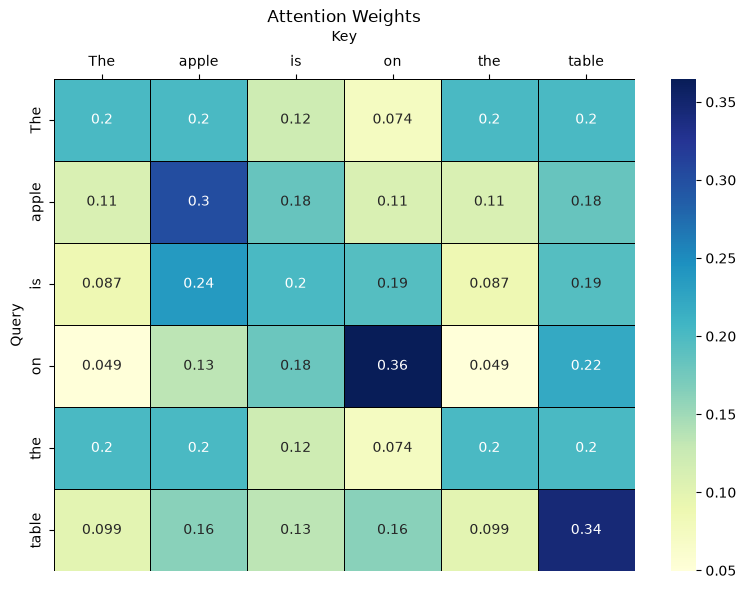

In [20]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt

tokens = ['The', 'apple', 'is', 'on', 'the', 'table']

plt.figure(figsize=(8, 6))
# 위에서 계산한 attn_weights를 numpy()를 변환하여 seaborn의 heatmap으로 시각화
ax = sns.heatmap(attn_weights.detach().numpy(), annot=True, 
                 cmap="YlGnBu", xticklabels=tokens, yticklabels=tokens,
                linewidths=0.5, linecolor='black')

# Title and labels
plt.title("Attention Weights")
ax.set_xlabel("Key", labelpad=10)
ax.set_ylabel("Query")

# Move xlabel and xticklabels to top
ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()

plt.tight_layout()
plt.show()

## 전체 토큰의 context vector 값 구하기

- 문장 문맥이 반영된 전체 토큰들의 context vector들은  
attention weights @ V(여기서 V는 전체 토큰들 = token_embeddings) 구할 수 있음

In [21]:
# 모든 token들에 대한 context vector들을 matrix multiplication으로 구하기

queries = token_embeddings.clone()
keys = token_embeddings.clone()
values = token_embeddings.clone()

attn_weights = F.softmax(queries @ keys.T, dim = -1)
print(f"attn_weights : \n{attn_weights}")

attn_weights : 
tensor([[0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829],
        [0.0871, 0.2367, 0.2017, 0.1938, 0.0871, 0.1938],
        [0.0494, 0.1342, 0.1811, 0.3647, 0.0494, 0.2212],
        [0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.0986, 0.1626, 0.1332, 0.1626, 0.0986, 0.3443]])


In [22]:
# attention weight와 values의 내적으로 context vector를 구함.
context_vecs = attn_weights @ values
print(f"context_vecs : \n{context_vecs}")

context_vecs : 
tensor([[0.8651, 0.4974, 0.3116],
        [0.7976, 0.6867, 0.3487],
        [0.7054, 0.7290, 0.4480],
        [0.5447, 0.7907, 0.6403],
        [0.8651, 0.4974, 0.3116],
        [0.7708, 0.6306, 0.5469]])


# Self Attention
## 학습 파라미터가 적용된 Query, Key, Value

* 입력 token embedding tensor만으로 구성된 query, key, value tensor 각각에 학습 파라미터(Learnable Parameter)를 부여하여 선형 변환하고 이를 이용하여 attention weights 및 context vector를 구함  
    * Q = X @ Wq 
    * K = X @ Wk
    * V = X @ Wv
* 일반적으로 Q, K , V 의 Shape는 모두 입력 tensor(여기서는 X)의 Shape와 동일.
* attention shape는 (seq_len, seq_len)
* context vector의 shape는 입력 tensor(여기서는 X)의 Shape와 동일
* 여기서는 입력 tensor의 shape를 (seq_len, emb_dim)인 2차원 shape로 가정. 실제 문장들은 여러개의 문장이 입력되므로 batch size를 감안하여 (batch_size, seq_len, emb_dim)이 입력됨.

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [24]:
tokens = ['The', 'apple', 'is', 'on', 'the', 'table']

# 테스트용 값으로 token embeddings tensor 값 생성.
token_embeddings = torch.tensor([
    [1.0, 0.0, 0.0],   # The
    [1.0, 1.0, 0.0],   # apple
    [0.5, 1.0, 0.5],   # is
    [0.0, 1.0, 1.0],   # on
    [1.0, 0.0, 0.0],   # the
    [1.0, 0.5, 1.0],   # table
])  # shape: (6, 3)

seq_len = token_embeddings.shape[0]
emb_dim = token_embeddings.shape[1]
print(f"seq_len:{seq_len}, emb_dim:{emb_dim}")

seq_len:6, emb_dim:3


## nn.Linear로 Wq, Wk, Wv를 token embedding에 적용

In [25]:
sample_linear = nn.Linear(in_features=3, out_features=3, bias=False)
sample_linear.weight.shape

torch.Size([3, 3])

In [26]:
import torch
import torch.nn as nn

torch.manual_seed(2026)
linear_q = nn.Linear(in_features=emb_dim, out_features=emb_dim, bias=False)
linear_k = nn.Linear(in_features=emb_dim, out_features=emb_dim, bias=False)
linear_v = nn.Linear(in_features=emb_dim, out_features=emb_dim, bias=False)

query = linear_q(token_embeddings)
key = linear_k(token_embeddings)
value = linear_v(token_embeddings)

print(f"linear_q learnable parameter shape: {linear_q.weight.shape}")
print(f"query shape: {query.shape} \nquery: {query}")
print(f"key shape: {key.shape} \nkey: {key}")
print(f"value shape: {value.shape} \nvalue: {value}")

linear_q learnable parameter shape: torch.Size([3, 3])
query shape: torch.Size([6, 3]) 
query: tensor([[-0.4013, -0.5031,  0.2981],
        [-0.6877, -1.0589, -0.2782],
        [-0.3537, -0.8105, -0.3128],
        [-0.0197, -0.5621, -0.3475],
        [-0.4013, -0.5031,  0.2981],
        [-0.2778, -0.7874,  0.2388]], grad_fn=<MmBackward0>)
key shape: torch.Size([6, 3]) 
key: tensor([[-0.5237,  0.2588, -0.1880],
        [-0.1623,  0.4212,  0.2878],
        [-0.0763,  0.2335,  0.4954],
        [ 0.0097,  0.0459,  0.7031],
        [-0.5237,  0.2588, -0.1880],
        [-0.6947,  0.2235,  0.2772]], grad_fn=<MmBackward0>)
value shape: torch.Size([6, 3]) 
value: tensor([[0.0078, 0.3148, 0.3090],
        [0.5099, 0.5562, 0.0117],
        [0.4679, 0.4181, 0.0804],
        [0.4259, 0.2801, 0.1491],
        [0.0078, 0.3148, 0.3090],
        [0.1826, 0.4742, 0.6068]], grad_fn=<MmBackward0>)


### attention scores와 attention weights 계산
- attention scores 계산 시 embedding dim의 루트값으로 나누는 scale 적용

In [27]:
import math

scale = math.sqrt(emb_dim)
# scale = emb_dim ** 0.5
print(f"emb_dim: {emb_dim}")
print(f"scale: {scale}") 

emb_dim: 3
scale: 1.7320508075688772


In [28]:
#  attention scores 계산 시 embedding dim의 루트값으로 나누는 scale 적용
attention_scores = query @ key.transpose(0, 1) / scale # key.T
print(f"attention_scores:\n{attention_scores}\nattention_scores shape:{attention_scores.shape}")

attention_weights = F.softmax(attention_scores, dim=-1)
print(f"attention_weights:\n{attention_weights}\nattention_weights shape:{attention_weights.shape}")

attention_scores:
tensor([[ 0.0138, -0.0352,  0.0351,  0.1054,  0.0138,  0.1437],
        [ 0.0799, -0.2393, -0.1920, -0.1448,  0.0799,  0.0947],
        [ 0.0198, -0.2159, -0.1832, -0.1504,  0.0198, -0.0128],
        [-0.0403, -0.1926, -0.1743, -0.1560, -0.0403, -0.1202],
        [ 0.0138, -0.0352,  0.0351,  0.1054,  0.0138,  0.1437],
        [-0.0596, -0.1257, -0.0256,  0.0745, -0.0596,  0.0480]],
       grad_fn=<DivBackward0>)
attention_scores shape:torch.Size([6, 6])
attention_weights:
tensor([[0.1611, 0.1534, 0.1645, 0.1765, 0.1611, 0.1834],
        [0.1886, 0.1371, 0.1437, 0.1506, 0.1886, 0.1914],
        [0.1846, 0.1458, 0.1507, 0.1557, 0.1846, 0.1787],
        [0.1803, 0.1548, 0.1577, 0.1606, 0.1803, 0.1664],
        [0.1611, 0.1534, 0.1645, 0.1765, 0.1611, 0.1834],
        [0.1606, 0.1503, 0.1661, 0.1836, 0.1606, 0.1788]],
       grad_fn=<SoftmaxBackward0>)
attention_weights shape:torch.Size([6, 6])


### scaled dot product 적용 테스트

- 앱력 embedding 차원이 클 수록 dot product 값이 커짐.
- softmax 값이 매우 sharp(표준 편차가 커짐)하게 되면서 특정 토큰에 attention이 집중되는 현상 발생
- 학습시 Gradient값이 매우 불안정하게 됨
- 입력 embedding 차원 수의 제곱근으로 scale 적용시 보다 안정적으로 attention score/weights가 생성되며 안정된 학습 가능

In [29]:
# attention weights와 attention scores 계산 함수 정의
def do_test_with_scale(embeddings, use_scale = True):
    seq_len = embeddings.shape[0]
    emb_dim = embeddings.shape[1]

    torch.manual_seed(2026)
    linear_q = nn.Linear(in_features=emb_dim, out_features=emb_dim, bias=False)
    linear_k = nn.Linear(in_features=emb_dim, out_features=emb_dim, bias=False)
    linear_v = nn.Linear(in_features=emb_dim, out_features=emb_dim, bias=False)

    query = linear_q(embeddings)
    key = linear_k(embeddings)
    value = linear_v(embeddings)

    scale = math.sqrt(emb_dim) if use_scale else 1.0  # use_scale이 False이면 scale 적용하지 않음
    attention_scores = query @ key.transpose(0, 1) / scale # key.T
    attention_weights = F.softmax(attention_scores, dim=-1)

    return attn_weights, attention_scores
    

In [30]:
#
torch.manual_seed(2026)

emb_dims = [16, 256] # embedding 크기 변화하면서 테스트하기
seq_len = 100
for emb_dim in emb_dims :
    embeddings = torch.randn(seq_len, emb_dim)
    for scale_option in [False, True]: # use_scale True/False 인 경우 테스트
        print(f"\n#### embeddings dim size:{embeddings.shape[-1]} scale_option={scale_option}")
        attn_weights, attn_scores = do_test_with_scale(embeddings, use_scale=scale_option)
        print("Scores mean:", attn_scores.mean().item(), "std:", attn_scores.std().item())
        print("Scores max:", attn_scores.max().item(), "min:", attn_scores.min().item())
        print("Attn weights mean:", attn_weights.mean().item(), "std:", attn_weights.std().item())
        print("Attn weights max:", attn_weights.max().item(), "min:", attn_weights.min().item())





#### embeddings dim size:16 scale_option=False
Scores mean: 0.01642385683953762 std: 1.331297516822815
Scores max: 6.413196563720703 min: -7.306554317474365
Attn weights mean: 0.1666666716337204 std: 0.07404539734125137
Attn weights max: 0.3647417426109314 min: 0.0493624247610569

#### embeddings dim size:16 scale_option=True
Scores mean: 0.004105964209884405 std: 0.33282437920570374
Scores max: 1.6032991409301758 min: -1.8266385793685913
Attn weights mean: 0.1666666716337204 std: 0.07404539734125137
Attn weights max: 0.3647417426109314 min: 0.0493624247610569

#### embeddings dim size:256 scale_option=False
Scores mean: 0.09590401500463486 std: 5.59548282623291
Scores max: 20.433433532714844 min: -21.939023971557617
Attn weights mean: 0.1666666716337204 std: 0.07404539734125137
Attn weights max: 0.3647417426109314 min: 0.0493624247610569

#### embeddings dim size:256 scale_option=True
Scores mean: 0.005994000937789679 std: 0.3497176766395569
Scores max: 1.2770895957946777 min: -1.371

[해석]

## Self Attention 모듈화 구현
- 3차원 입력(batch_size, seq_len, emb_dim)을 가정하여 구현
- attention weights에 dropout 적용

In [31]:
import math

class SelfAttention_1th(nn.Module):
    def __init__(self, emb_dim, dropout=0.1):
        super().__init__()

        self.linear_q = nn.Linear(emb_dim, emb_dim) # bias = True
        self.linear_k = nn.Linear(emb_dim, emb_dim) # bias = True
        self.linear_v = nn.Linear(emb_dim, emb_dim) # bias = True

        self.scale = math.sqrt(emb_dim)
        self.dropout = nn.Dropout(dropout)

    # 입력 x는 batch를 포함한 (batch_size, seq_len, emb_dim) shape의 3차원 tensor
    def forward(self, x):
        query = self.linear_q(x)
        key = self.linear_k(x)
        value = self.linear_v(x)

        # key는 batch가 아닌 1, 2차원이 서로 tenspose 되어야함.
        # key.transpose(-2, -1)
        scores = torch.matmul(query, key.transpose(1, 2)) / self.scale

        attn_weights = F.softmax(scores, dim = -1)

        # attention weights에 dropout 적용
        atten_weights = self.dropout(attn_weights)

        # context vector 생성
        context = torch.matmul(attn_weights, value)

        return context, attn_weights


In [32]:
batch_size = 8
seq_len = 100
emb_dim = 128

sample_token_embedding = torch.randn((batch_size, seq_len, emb_dim))
print(f"sample_token_embedding.shape: {sample_token_embedding.shape}")

sample_token_embedding.shape: torch.Size([8, 100, 128])


In [33]:
self_attention = SelfAttention_1th(emb_dim, dropout=0.1)
context, attn_weights = self_attention(sample_token_embedding)

# atten_weights의  shape는 (batch_size, seq_len, seq_len)
# context의 shape는 (batch_size, seq_len, emb_dim)
print(f"attn_weights shape: {attn_weights.shape}\ncontext shape: {context.shape}")


attn_weights shape: torch.Size([8, 100, 100])
context shape: torch.Size([8, 100, 128])


# Multi-Head Self Attention

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

In [35]:
class MultiHeadAttention(nn.Module):
    def __init__(self, emb_dim, num_heads, dropout=0.1):
        super().__init__()
        # emb_dim의 num_heads로 정확히 나눠지지 않으면 오류 발생시킴
        assert emb_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim = emb_dim // num_heads

        # query, key, value를 위한 Linear Layers
        self.linear_q = nn.Linear(emb_dim, emb_dim)
        self.linear_k = nn.Linear(emb_dim, emb_dim)
        self.linear_v = nn.Linear(emb_dim, emb_dim)

        # 최종 context 변환을 위한 Linear layer
        self.linear_out = nn.Linear(emb_dim, emb_dim)
        self.dropout = nn.Dropout(dropout)

    # cross attention일 경우 사이즈가 다른 query, key, value 각자가 인자로 들어올 수 있음.
    def forward(self, x, mask=None): 
        # 입력 x의 shape는 (batch_size, seq_len, emb_dim)
        batch_size, seq_len, emb_dim = x.size()

        # Linear layer 적용하여 query, key, value 생성
        query = self.linear_q(x)  # (batch_size, seq_len, emb_dim)
        key = self.linear_k(x)
        value = self.linear_v(x)

        
        # multi head self attention 적용을 위해 query, key, value를 num_heads 레벨로 (배치포함) 4차원 텐서로 변환
        # embedding dim를 num_heads x head_dim으로 차원을 높여 분할. 
        # 이후 (batch_size, num_heads, seq_len, head_dim)으로 변환 

        query = query.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        key = key.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        value = value.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        # num_heads 레벨로 분할된 (배치포함) 4차원 query와 keys에 Scaled dot-product attention 적용
        # (batch_size, num_heads, seq_len, seq_len)
        scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # attention masking 처리

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        # attention weights 및 dropout 적용
        atten_weights = F.softmax(scores, dim = -1)
        atten_weights = self.dropout(atten_weights)

        # heads 별 context vector 생성.
        context_by_heads = torch.matmul(atten_weights, value) # (batch_size, num_heads, seq_len, head_dim)

        # Concatenate head별 context vector -> tensor별 병합(num_heads * num_heads)하는 방식으로 적용
        # (b_size, num_heads, seq_len, head_dim) -> (b_size, seq_len, num_heads, head_dim) -> (b_size, seq_len, num_heads * head_dim)
        context = context_by_heads.transpose(1, 2).contiguous().view(batch_size, seq_len, emb_dim)

        # context의 최종 linear 변환
        context = self.linear_out(context) # (batch_sizem seq_len, emb_dim)

        return context, atten_weights, scores

In [36]:
emb_dim = 256
num_heads = 8
seq_len = 100
batch_size = 32

mha = MultiHeadAttention(emb_dim = emb_dim, num_heads = num_heads)

# 테스트용 입력 토큰 embedding 생성
x = torch.randn(batch_size, seq_len, emb_dim)

context, atten_weights, scores = mha(x)

print("context shape: ", context.shape)  # (32, 100, 256)
print("Attention weights shape: ", atten_weights.shape)  # (32, 8, 100, 1|00)

context shape:  torch.Size([32, 100, 256])
Attention weights shape:  torch.Size([32, 8, 100, 100])


## Attention Masking 처리
- 문장의 Padding('[PAD]') 값은 Attention weights에서 0으로 처리하여 context vector에서 이를 반영하지 않도록 함.
- 이를 위해 Attention scores에서 padding에 해당하는 토큰들의 score 값을 -inf로 설정하면 attention weights에서 softmax 적용시 0으로 weight 값이 설정됨

In [37]:
from transformers import BertTokenizer, BertModel

# Bert tokenizer 로딩
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# 길이가 서로 다른 두개의 문장 token화
sentences = [
    "Good Morning",
    "How are you feeling today?"
]

tokens = tokenizer(sentences,
                padding = "max_length",
                max_length = 10,
                return_tensor = "pt"
            )
# tokens
input_ids = tokens["input_ids"]  # (bathc_size, seq_len)
# input_ids

# # attention_mask는 [PAD]가 아닌 Token의 경우 1, [PAD]인 경우 0을 가짐
attention_mask = tokens["attention_mask"]    # (batch_size, seq_len)   
attention_mask

[[1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 0, 0]]

In [38]:
print(f"Input IDs:\n{input_ids}, \nattention mask:\n{attention_mask}")
print()
print(f"First Sentence Tokens:{tokenizer.convert_ids_to_tokens(input_ids[0])}")
print(f"Second Sentence Tokens:{tokenizer.convert_ids_to_tokens(input_ids[1])}")

Input IDs:
[[101, 2204, 2851, 102, 0, 0, 0, 0, 0, 0], [101, 2129, 2024, 2017, 3110, 2651, 1029, 102, 0, 0]], 
attention mask:
[[1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 0, 0]]

First Sentence Tokens:['[CLS]', 'good', 'morning', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Second Sentence Tokens:['[CLS]', 'how', 'are', 'you', 'feeling', 'today', '?', '[SEP]', '[PAD]', '[PAD]']


In [39]:
emb_dim = 256
num_heads = 8
seq_len = 10
batch_size = 2

mha = MultiHeadAttention(emb_dim=emb_dim, num_heads=num_heads)
# 입력을 문장 토큰이 10개이고 embedding size가 256인 두개 문장의 embedding tensor 가정. 
x = torch.randn(batch_size, seq_len, emb_dim)

# 입력 tensor를 attention mask 없이 적용. 
context, attn_weights, scores = mha(x)
print("context shape:", context.shape)
print("Attention weights shape:", attn_weights.shape)
print("Attention scores shape:", scores.shape)
# 첫번째 문장에 대한 첫번째 head의 attention score와 weights
print(f"첫번째 문장에 대한 첫번째 head의 attention score without mask:\n{scores[0, 0, :, :]}")
print(f"첫번째 문장에 대한 첫번째 head의 attention weights without mask:\n{attn_weights[0, 0, :, :]}")

context shape: torch.Size([2, 10, 256])
Attention weights shape: torch.Size([2, 8, 10, 10])
Attention scores shape: torch.Size([2, 8, 10, 10])
첫번째 문장에 대한 첫번째 head의 attention score without mask:
tensor([[-0.1738, -0.1648, -0.1697,  0.2093, -0.2770, -0.4533,  0.2662,  0.6879,
         -0.1216,  0.6730],
        [ 0.0326, -0.5376,  0.4650,  0.3172,  0.1857,  0.0956,  0.6869, -0.0205,
          0.1079,  0.3014],
        [ 0.1578, -0.3283, -0.6725,  0.3135, -0.1536,  0.2682,  0.1595, -0.1989,
          0.4163,  0.3827],
        [ 0.1672,  0.0552,  0.0051, -0.0462, -0.3033,  0.3314, -0.3493,  0.2217,
          0.6163,  0.4501],
        [ 0.3680,  0.2663, -0.5728, -0.1852, -0.8668, -0.0104,  0.0316,  0.2260,
          0.2435, -0.0270],
        [-0.4712, -0.5305, -0.0601, -0.6109, -0.1375, -0.0208, -0.1728, -0.1838,
         -0.1371, -0.6960],
        [-0.0962, -0.1902,  0.1486, -0.2490, -0.4615,  0.2252,  0.1723,  0.2115,
          0.2526,  0.0222],
        [-0.1072, -0.3478,  0.0211,  0.6029

In [40]:
#scores가 4차원(b_size, n_heads, seq_len, seq_len)이므로 
# mask도 (b_size, seq_len) -> (b_size, 1, seq_len) -> (b_size, 1, 1, seq_len) 형태의 4차원으로 변환
attention_mask = torch.tensor(attention_mask)
# mask = attention_mask.unsqueeze(0).unsqueeze(0)
mask = attention_mask.unsqueeze(1).unsqueeze(2)
# mask.shape

# 입력 tensor를 attention mask와 함께 적용
# context, attn_weights, scores = mha(x, mask=mask)
# 첫번째 문장에 대한 첫번째 head의 attention score
print(f"첫번째 문장에 대한 첫번째 head의 attention scores with mask:\n{scores[0, 0, :, :]}")
print(f"첫번째 문장에 대한 첫번째 head의 attention weights with mask:\n{attn_weights[0, 0, :, :]}")

첫번째 문장에 대한 첫번째 head의 attention scores with mask:
tensor([[-0.1738, -0.1648, -0.1697,  0.2093, -0.2770, -0.4533,  0.2662,  0.6879,
         -0.1216,  0.6730],
        [ 0.0326, -0.5376,  0.4650,  0.3172,  0.1857,  0.0956,  0.6869, -0.0205,
          0.1079,  0.3014],
        [ 0.1578, -0.3283, -0.6725,  0.3135, -0.1536,  0.2682,  0.1595, -0.1989,
          0.4163,  0.3827],
        [ 0.1672,  0.0552,  0.0051, -0.0462, -0.3033,  0.3314, -0.3493,  0.2217,
          0.6163,  0.4501],
        [ 0.3680,  0.2663, -0.5728, -0.1852, -0.8668, -0.0104,  0.0316,  0.2260,
          0.2435, -0.0270],
        [-0.4712, -0.5305, -0.0601, -0.6109, -0.1375, -0.0208, -0.1728, -0.1838,
         -0.1371, -0.6960],
        [-0.0962, -0.1902,  0.1486, -0.2490, -0.4615,  0.2252,  0.1723,  0.2115,
          0.2526,  0.0222],
        [-0.1072, -0.3478,  0.0211,  0.6029,  0.0062,  0.1722,  0.5413,  0.8257,
         -0.1488,  0.0314],
        [-0.1507,  0.0596,  0.0328,  0.2595, -0.2444, -0.5073,  0.3881, -0.1519

In [41]:
# pytorch의 softmax 함수는 -inf를 0으로 변환(NaN 아님)
x = torch.tensor([1.0, 2.0, float('-inf')])
print(F.softmax(x, dim = -1))

print(F.softmax(torch.tensor([1.0, float('-inf')]), dim = -1))
print(F.softmax(torch.tensor(float('-inf')), dim = -1))

tensor([0.2689, 0.7311, 0.0000])
tensor([1., 0.])
tensor(nan)
